# Sprint 3: Isolation Forest + LSTM Autoencoder + SHAP
**Project:** Smart Building Energy Anomaly Detection
**Authors:** Dharmik Champaneri, Hardip Zanzmera, Sauravkumar Pandya, Dharmin Patel
**Supervisor:** Shan Faiz | UEAS Potsdam

Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Clone repo

In [4]:
import os
from google.colab import userdata

os.environ['GITHUB_TOKEN'] = userdata.get('GITHUB_TOKEN')
token = os.environ['GITHUB_TOKEN']

!git clone https://{token}@github.com/DevDharmik/Smart-Building-Anomaly-Detection.git \
  /content/smart-building-anomaly-detection

!git -C /content/smart-building-anomaly-detection config user.email "dharmikchampaneri@gmail.com"
!git -C /content/smart-building-anomaly-detection config user.name "DevDharmik"
print("✅ Repo cloned")

Cloning into '/content/smart-building-anomaly-detection'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 51 (delta 16), reused 33 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 983.61 KiB | 16.96 MiB/s, done.
Resolving deltas: 100% (16/16), done.
✅ Repo cloned


Install


In [5]:
!pip install shap tensorflow scikit-learn pandas numpy matplotlib seaborn -q
print("✅ Done")

✅ Done


Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input
from tensorflow.keras.callbacks import EarlyStopping

import shap

tf.random.set_seed(42)
np.random.seed(42)
pd.set_option('display.max_columns', None)

print(f"✅ TF {tf.__version__} | SHAP {shap.__version__}")

✅ TF 2.20.0 | SHAP 0.52.0


Load data from SQLite

In [7]:
conn = sqlite3.connect('/content/drive/MyDrive/smart_building.db')
df = pd.read_sql('SELECT * FROM energy_features', conn)
conn.close()

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['building_id', 'timestamp']).reset_index(drop=True)

print(f"✅ Loaded: {df.shape}")
df.head()

✅ Loaded: (4911000, 23)


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,hour,day_of_week,month,is_weekend,day_of_year,rolling_mean_24h,rolling_std_24h,lag_7day,z_score,zscore_anomaly,iqr_lower,iqr_upper,iqr_anomaly,anomaly_label
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,0,4,1,0,1,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,1,4,1,0,1,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN,2,4,1,0,1,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN,3,4,1,0,1,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN,4,4,1,0,1,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0


Feature matrix

In [8]:
FEATURES = [
    'meter_reading', 'rolling_mean_24h', 'rolling_std_24h',
    'lag_7day', 'hour', 'day_of_week', 'month', 'is_weekend'
]

df_model = df[FEATURES + ['building_id', 'timestamp',
                           'anomaly_label', 'zscore_anomaly', 'iqr_anomaly']].dropna().copy()

print(f"Rows: {df_model.shape[0]:,}")
print(f"Anomaly label rate: {df_model['anomaly_label'].mean()*100:.2f}%")

Rows: 4,911,000
Anomaly label rate: 4.01%


Scale

In [9]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_model[FEATURES])
print("✅ Scaled to [0, 1]")

✅ Scaled to [0, 1]


Train Isolation Forest


In [10]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.09,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_scaled)
print("✅ Isolation Forest trained")

✅ Isolation Forest trained


IF predictions


In [11]:
if_preds = iso_forest.predict(X_scaled)      # -1 = anomaly, 1 = normal
if_scores = iso_forest.decision_function(X_scaled)  # lower = more anomalous

df_model['if_anomaly'] = (if_preds == -1).astype(int)
df_model['if_score']   = if_scores

print(f"IF anomaly rate: {df_model['if_anomaly'].mean()*100:.2f}%")
print(f"Total flagged:   {df_model['if_anomaly'].sum():,}")

IF anomaly rate: 9.00%
Total flagged:   441,990


IF visualization


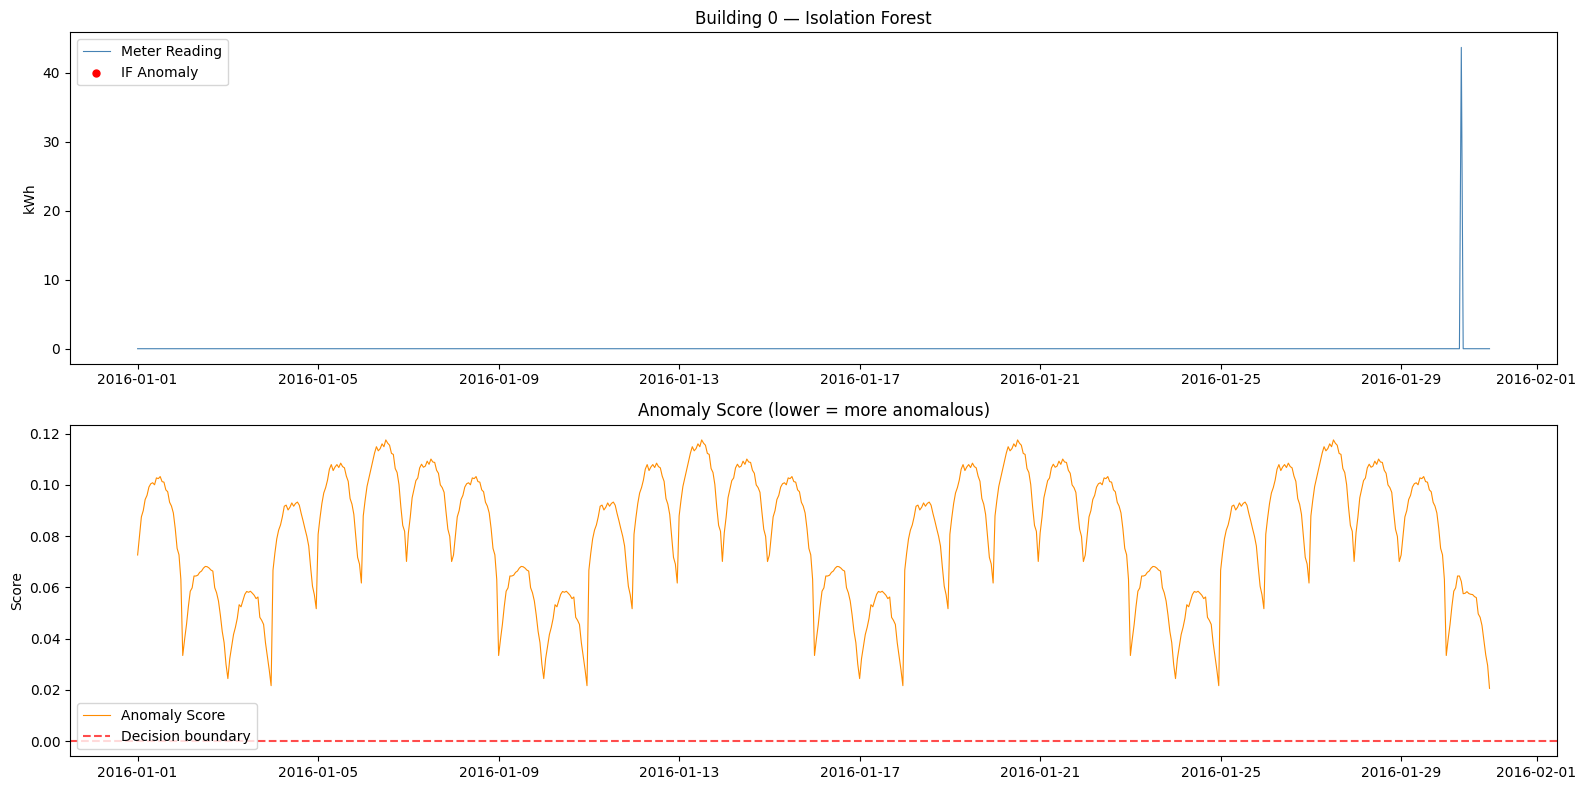

✅ Saved


In [12]:
sample_bid = df_model['building_id'].unique()[0]
sample = df_model[df_model['building_id'] == sample_bid].set_index('timestamp').head(720)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(sample.index, sample['meter_reading'],
             color='steelblue', linewidth=0.8, label='Meter Reading')
axes[0].scatter(sample[sample['if_anomaly']==1].index,
                sample[sample['if_anomaly']==1]['meter_reading'],
                color='red', s=25, zorder=5, label='IF Anomaly')
axes[0].set_title(f'Building {sample_bid} — Isolation Forest')
axes[0].set_ylabel('kWh')
axes[0].legend()

axes[1].plot(sample.index, sample['if_score'],
             color='darkorange', linewidth=0.8, label='Anomaly Score')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Decision boundary')
axes[1].set_title('Anomaly Score (lower = more anomalous)')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/if_anomalies.png', dpi=150)
plt.show()
print("✅ Saved")

LSTM sequences

In [13]:
SEQUENCE_LEN  = 24
FEATURES_LSTM = ['meter_reading', 'rolling_mean_24h', 'rolling_std_24h',
                 'lag_7day', 'hour', 'is_weekend']

def make_sequences(data, seq_len):
    return np.array([data[i:i+seq_len] for i in range(len(data)-seq_len+1)])

lstm_bid  = df_model['building_id'].unique()[0]
lstm_data = df_model[df_model['building_id'] == lstm_bid][FEATURES_LSTM].values

lstm_scaler = MinMaxScaler()
lstm_scaled = lstm_scaler.fit_transform(lstm_data)

X_seq = make_sequences(lstm_scaled, SEQUENCE_LEN)
print(f"✅ Sequences: {X_seq.shape}  →  (samples, timesteps, features)")

✅ Sequences: (8761, 24, 6)  →  (samples, timesteps, features)


Build LSTM Autoencoder

In [14]:
n_timesteps = X_seq.shape[1]
n_features  = X_seq.shape[2]

inputs  = Input(shape=(n_timesteps, n_features))
encoded = LSTM(64, activation='relu', return_sequences=False)(inputs)
decoded = RepeatVector(n_timesteps)(encoded)
decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)
outputs = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 6)          │           390 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,590 (201.52 KB)

 Trainable params: 51,590 (201.52 KB)

 Non-trainable params: 0 (0.00 B)

Train

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=1)

history = autoencoder.fit(
    X_seq, X_seq,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)
print(f"✅ Best val_loss: {min(history.history['val_loss']):.6f}")

Epoch 1/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.0568 - val_loss: 0.0351
Epoch 2/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0449 - val_loss: 0.0338
Epoch 3/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0428 - val_loss: 0.0323
Epoch 4/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0313 - val_loss: 0.0310
Epoch 5/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0284 - val_loss: 0.0298
Epoch 6/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0269 - val_loss: 0.0282
Epoch 7/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0246 - val_loss: 0.0266
Epoch 8/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0223 - val_loss: 0.0249
Epoch 9/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0213 - val_loss: 0.0241
Epoch 10/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0236 - val_loss: 0.0238
Epoch 11/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0217 - val_loss: 0.0228
Epoch 12/30
124/124 ━━━━━━━━━━━━━━━━━━━━

Loss curve


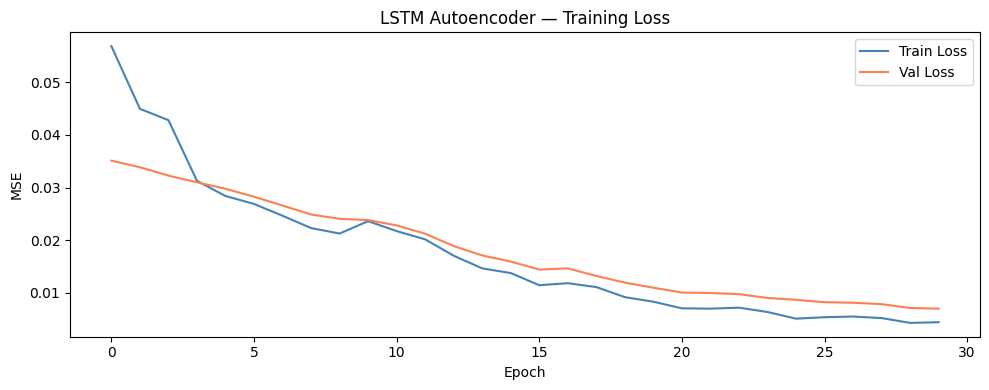

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='coral')
plt.title('LSTM Autoencoder — Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/lstm_loss.png', dpi=150)
plt.show()

 Reconstruction error + threshold


In [17]:
X_pred = autoencoder.predict(X_seq, verbose=0)
recon_errors = np.mean(np.mean(np.square(X_seq - X_pred), axis=2), axis=1)

threshold_lstm     = np.percentile(recon_errors, 95)
lstm_anomaly_flags = (recon_errors > threshold_lstm).astype(int)

print(f"Threshold (95th pct): {threshold_lstm:.6f}")
print(f"LSTM anomaly rate:    {lstm_anomaly_flags.mean()*100:.2f}%")
print(f"Total flagged:        {lstm_anomaly_flags.sum():,}")

Threshold (95th pct): 0.016258
LSTM anomaly rate:    5.00%
Total flagged:        438


LSTM visualization

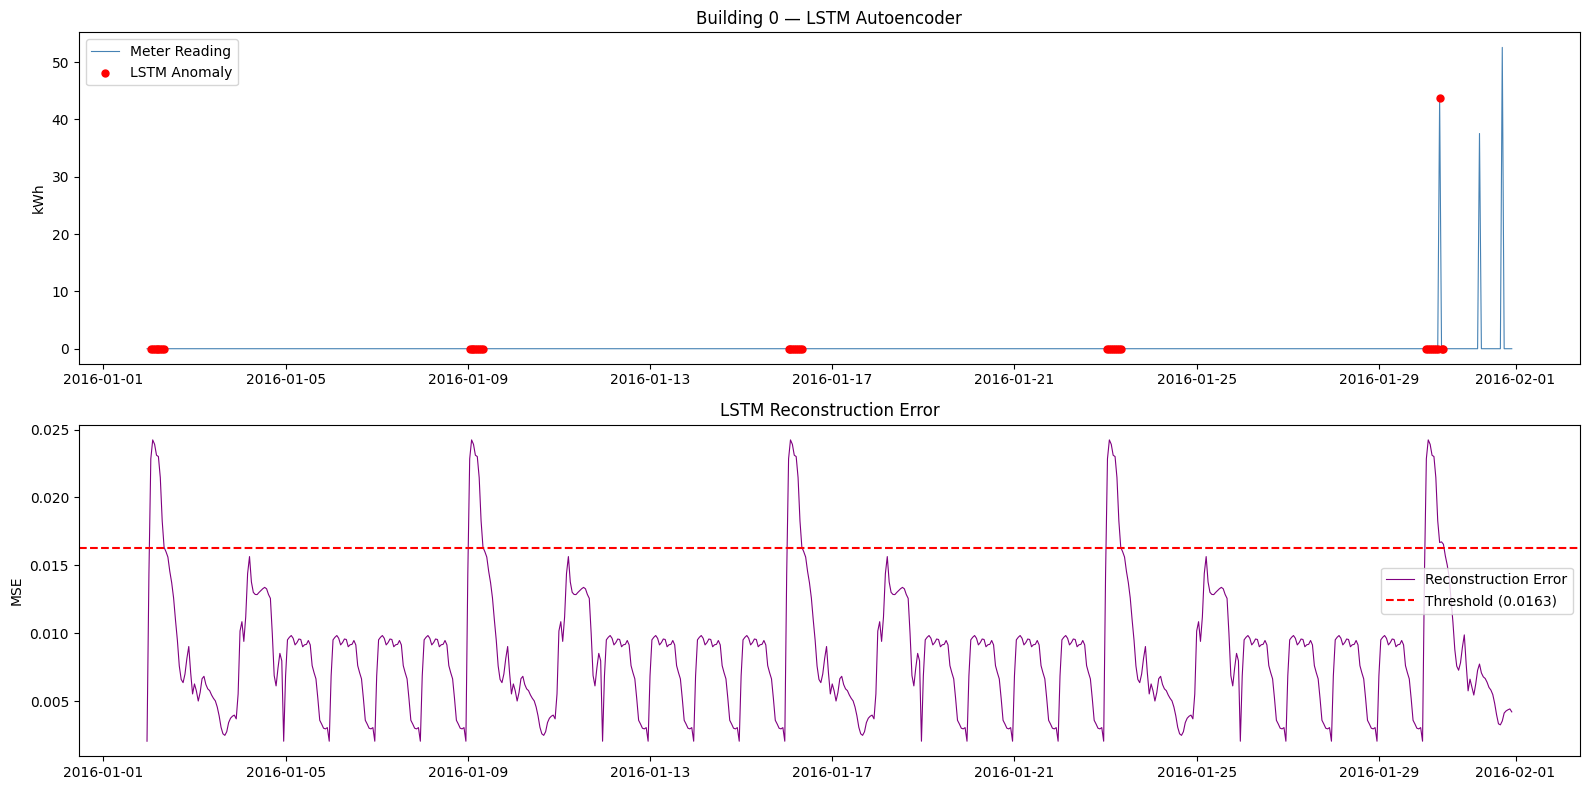

✅ Saved


In [18]:
offset   = SEQUENCE_LEN - 1
lstm_df  = df_model[df_model['building_id'] == lstm_bid].iloc[offset:].copy().reset_index(drop=True)
lstm_df['lstm_recon_error'] = recon_errors
lstm_df['lstm_anomaly']     = lstm_anomaly_flags

sample_lstm = lstm_df.set_index('timestamp').head(720)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(sample_lstm.index, sample_lstm['meter_reading'],
             color='steelblue', linewidth=0.8, label='Meter Reading')
axes[0].scatter(sample_lstm[sample_lstm['lstm_anomaly']==1].index,
                sample_lstm[sample_lstm['lstm_anomaly']==1]['meter_reading'],
                color='red', s=25, zorder=5, label='LSTM Anomaly')
axes[0].set_title(f'Building {lstm_bid} — LSTM Autoencoder')
axes[0].set_ylabel('kWh')
axes[0].legend()

axes[1].plot(sample_lstm.index, sample_lstm['lstm_recon_error'],
             color='purple', linewidth=0.8, label='Reconstruction Error')
axes[1].axhline(y=threshold_lstm, color='red', linestyle='--',
                label=f'Threshold ({threshold_lstm:.4f})')
axes[1].set_title('LSTM Reconstruction Error')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/lstm_anomalies.png', dpi=150)
plt.show()
print("✅ Saved")Method comparison

Method comparison

In [19]:
print(f"=== Anomaly Rate Comparison (Building {lstm_bid}) ===")
compare = lstm_df[['zscore_anomaly','iqr_anomaly','if_anomaly','lstm_anomaly','anomaly_label']]
labels  = ['Z-score','IQR','Isolation Forest','LSTM Autoencoder','Combined Label (S2)']

for col, label in zip(compare.columns, labels):
    rate  = compare[col].mean() * 100
    total = compare[col].sum()
    print(f"  {label:<28}: {rate:.2f}%  ({total:,} flags)")

=== Anomaly Rate Comparison (Building 0) ===
  Z-score                     : 0.59%  (52 flags)
  IQR                         : 3.47%  (304 flags)
  Isolation Forest            : 0.18%  (16 flags)
  LSTM Autoencoder            : 5.00%  (438 flags)
  Combined Label (S2)         : 3.47%  (304 flags)


Agreement heatmap

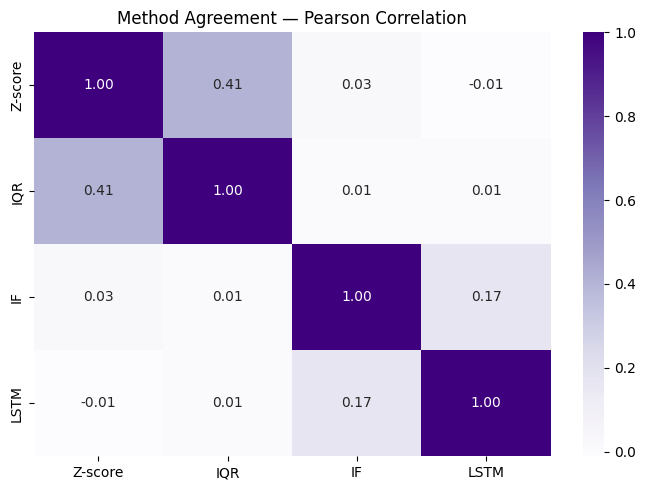

In [20]:
agree_cols = ['zscore_anomaly','iqr_anomaly','if_anomaly','lstm_anomaly']
agree_mat  = lstm_df[agree_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(agree_mat, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=['Z-score','IQR','IF','LSTM'],
            yticklabels=['Z-score','IQR','IF','LSTM'])
plt.title('Method Agreement — Pearson Correlation')
plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/method_agreement.png', dpi=150)
plt.show()SHAP explainer

SHAP explainer

In [21]:
sample_idx  = np.random.choice(len(X_scaled), size=2000, replace=False)
X_sample    = X_scaled[sample_idx]

explainer   = shap.TreeExplainer(iso_forest)
shap_values = explainer.shap_values(X_sample)

print(f"✅ SHAP values: {shap_values.shape}")

✅ SHAP values: (2000, 8)


SHAP bar plot

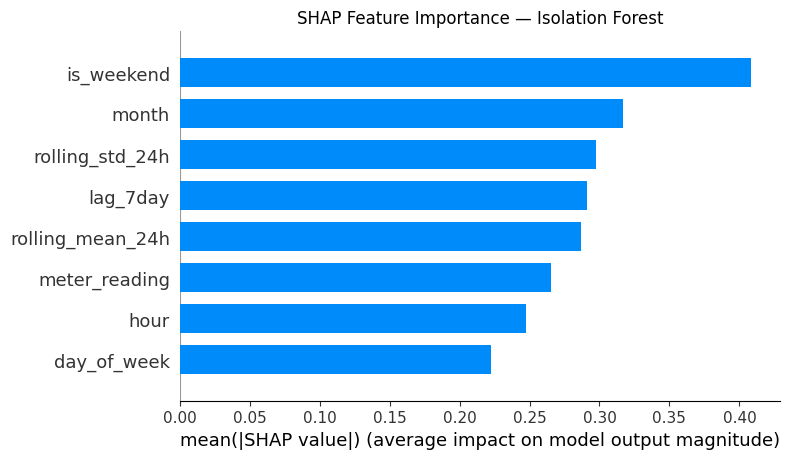

✅ Saved


In [22]:
shap.summary_plot(shap_values, X_sample,
                  feature_names=FEATURES, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Isolation Forest')
plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

SHAP beeswarm

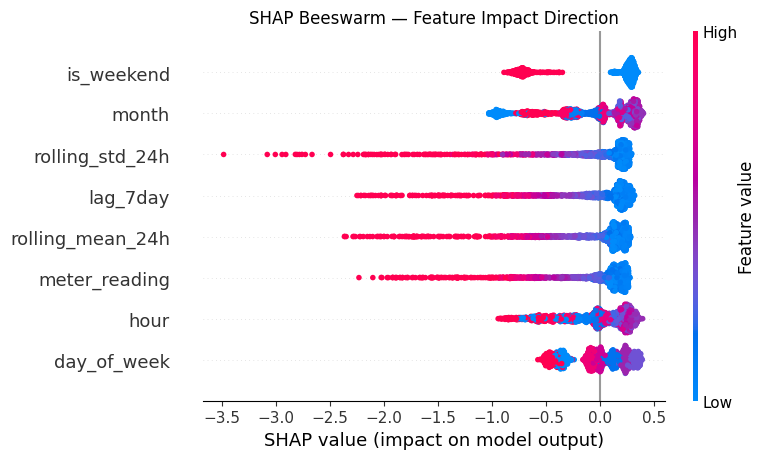

✅ Saved


In [23]:
shap.summary_plot(shap_values, X_sample,
                  feature_names=FEATURES, show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction')
plt.tight_layout()
plt.savefig('/content/smart-building-anomaly-detection/data/processed/shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

Save results to SQLite

In [24]:
df_save = df_model[['building_id','timestamp','meter_reading',
                     'anomaly_label','zscore_anomaly','iqr_anomaly',
                     'if_anomaly','if_score']].copy()

df_save['lstm_anomaly']     = np.nan
df_save['lstm_recon_error'] = np.nan
df_save.loc[lstm_df.index, 'lstm_anomaly']     = lstm_df['lstm_anomaly'].values
df_save.loc[lstm_df.index, 'lstm_recon_error'] = lstm_df['lstm_recon_error'].values

conn = sqlite3.connect('/content/drive/MyDrive/smart_building.db')
df_save.to_sql('anomaly_results', conn, if_exists='replace', index=False)
conn.close()

print(f"✅ anomaly_results saved | shape: {df_save.shape}")

✅ anomaly_results saved | shape: (4911000, 10)


Save LSTM model

In [25]:
autoencoder.save('/content/drive/MyDrive/lstm_autoencoder_sprint3.keras')
print("✅ Model saved to Drive")

✅ Model saved to Drive
